# Experiment No. 10

## Title
**To implement B-Spline Curve Generation using control points**

## Objective
To generate a smooth B-Spline curve using a set of control points and observe how the control polygon influences the shape of the curve.

## Theory
A B-Spline curve is a smooth piecewise polynomial curve used in computer graphics and geometric modeling. It is controlled by a set of control points, but the curve does not usually pass through all of them.

For a B-Spline curve, the general equation is:

$$
P(t) = \sum_{i=0}^{n} P_i N_{i,k}(t)
$$

where:

- $P_i$ = control points
- $N_{i,k}(t)$ = B-Spline basis function
- $k$ = degree of the curve
- $t$ = curve parameter

The basis function is defined recursively using the Cox-de Boor formula:

$$
N_{i,0}(t) =
\begin{cases}
1, & t_i \leq t < t_{i+1} \\
0, & otherwise
\end{cases}
$$

For degree $k$:

$$
N_{i,k}(t) =
\frac{t - t_i}{t_{i+k} - t_i}N_{i,k-1}(t)
+
\frac{t_{i+k+1} - t}{t_{i+k+1} - t_{i+1}}N_{i+1,k-1}(t)
$$

B-Spline curves are useful because they provide local control, smoothness, and flexibility in curve design.

## Procedure
1. Define a set of control points.
2. Choose the degree of the B-Spline curve.
3. Generate the knot vector.
4. Calculate the B-Spline basis functions.
5. Compute curve points using the weighted sum of control points.
6. Plot the control polygon and generated B-Spline curve.
7. Save the output image.

## Output
- Control points and control polygon
- Smooth B-Spline curve
- Output image saved as `Exp10_Output.png`

## Result and Discussion
The B-Spline curve was successfully generated using the given control points. The curve followed the general shape of the control polygon but did not necessarily pass through all control points. The result shows that B-Spline curves provide smoothness and local control, making them useful for curve modeling in computer graphics.

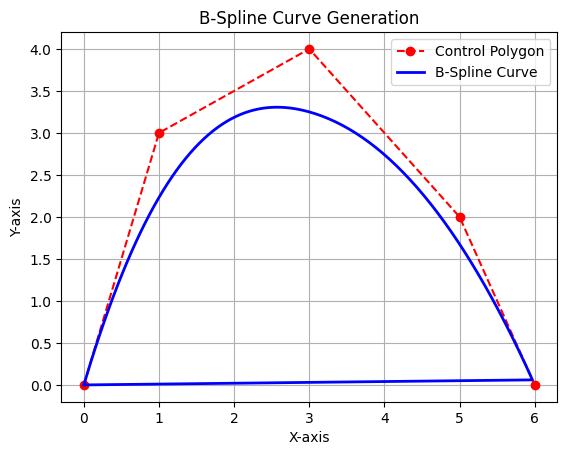

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def b_spline_basis(i, k, t, knots):
    if k == 0:
        if knots[i] <= t < knots[i + 1]:
            return 1
        return 0

    denominator1 = knots[i + k] - knots[i]
    denominator2 = knots[i + k + 1] - knots[i + 1]

    term1 = 0
    term2 = 0

    if denominator1 != 0:
        term1 = ((t - knots[i]) / denominator1) * b_spline_basis(i, k - 1, t, knots)

    if denominator2 != 0:
        term2 = ((knots[i + k + 1] - t) / denominator2) * b_spline_basis(i + 1, k - 1, t, knots)

    return term1 + term2

def b_spline_curve(control_points, degree, num_points=200):
    n = len(control_points) - 1
    knots = np.concatenate((
        np.zeros(degree),
        np.linspace(0, 1, n - degree + 2),
        np.ones(degree)
    ))

    curve_points = []

    for t in np.linspace(0, 1, num_points):
        point = np.zeros(2)

        for i in range(n + 1):
            basis = b_spline_basis(i, degree, t, knots)
            point += basis * control_points[i]

        curve_points.append(point)

    return np.array(curve_points)

# Define control points
control_points = np.array([
    [0, 0],
    [1, 3],
    [3, 4],
    [5, 2],
    [6, 0]
])

degree = 3
curve = b_spline_curve(control_points, degree)

plt.plot(control_points[:, 0], control_points[:, 1], "ro--", label="Control Polygon")
plt.plot(curve[:, 0], curve[:, 1], "b", linewidth=2, label="B-Spline Curve")

plt.title("B-Spline Curve Generation")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.grid(True)
plt.legend()
plt.savefig("Exp10_Output.png")
plt.show()